# ⚽ Midfielder Profiling — Serie A 2025/26 + Stanković

**Four profiles:** Defensive · Box-to-Box · Creative · Offensive

**Data:** All Serie A 2025/26 midfielders (MC, CAM, CDM, CM) ≥900 min + Aleksandar Stanković (Club Brugge, Belgium 25/26)

**Methodology:** possession-adjusted per-90 metrics · global percentile ranks · 4 profile-weighted composite scores

**Outputs:** Composite Ranking · Quantity vs Quality · Player Scouting Card (all-profile table) · Radar Explorer (4-profile overlay)

In [18]:
import pandas as pd
import numpy as np
import os, glob, warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

BASE         = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW          = os.path.join(BASE, 'data', 'raw')
BELGIUM_DIR  = os.path.join(BASE, 'Single Club Scraping', 'Club Brugge', 'Result_Belgium_25_26')
SEASON_TAG   = 'serie_a_2025_2026'
SEASON_LABEL = 'Serie A 25/26'
BELGIUM_LABEL= 'Belgium 25/26'
MIN_MINUTES  = 900
MF_POSITIONS = {'MC', 'CAM', 'CDM', 'CM'}

# Players Opta tags as CAM but are forwards, not midfielders
NON_MF_EXCLUSIONS = {
    'M. Soulé', 'Francisco Conceição', 'G. Scamacca',
}

PROFILE_COLORS = {
    'Defensive':  '#1f77b4',
    'Box-to-Box': '#2ca02c',
    'Creative':   '#ff7f0e',
    'Offensive':  '#d62728',
}
print('Config loaded ✓')


Config loaded ✓


In [19]:
# ── 4 Profile Definitions ────────────────────────────────────────────────────
PROFILES = {
    'Defensive': {
        'pillar_weights': {
            'Possession Regain':        0.40,
            'Positional Screening':     0.25,
            'Pressing & Counter-press': 0.20,
            'Distribution Security':    0.15,
        },
        'kpi_map': {
            'Possession Regain': {
                'tackles_won_p90':     {'weight': 0.35, 'negative': False},
                'interceptions_p90':   {'weight': 0.35, 'negative': False},
                'ball_recoveries_p90': {'weight': 0.30, 'negative': False},
            },
            'Positional Screening': {
                'clearances_p90': {'weight': 0.30, 'negative': False},
                'aerial_win_pct': {'weight': 0.40, 'negative': False},
                'duels_won_pct':  {'weight': 0.30, 'negative': False},
            },
            'Pressing & Counter-press': {
                'recovery_opp_half_p90': {'weight': 0.40, 'negative': False},
                'tackles_opp_half_p90':  {'weight': 0.40, 'negative': False},
                'turnovers_p90':         {'weight': 0.20, 'negative': True},
            },
            'Distribution Security': {
                'pass_completion_pct': {'weight': 0.55, 'negative': False},
                'turnovers_p90':       {'weight': 0.45, 'negative': True},
            },
        },
    },
    'Box-to-Box': {
        'pillar_weights': {
            'Build-up & Circulation': 0.25,
            'Progressive Passing':    0.30,
            'Defensive Contribution': 0.25,
            'Carrying & Switching':   0.20,
        },
        'kpi_map': {
            'Build-up & Circulation': {
                'pass_completion_pct':         {'weight': 0.35, 'negative': False},
                'total_passes_p90':            {'weight': 0.30, 'negative': False},
                'forward_pass_completion_pct': {'weight': 0.35, 'negative': False},
            },
            'Progressive Passing': {
                'progressive_passes_p90': {'weight': 0.25, 'negative': False},
                'final_third_passes_p90': {'weight': 0.25, 'negative': False},
                'forward_passes_p90':     {'weight': 0.25, 'negative': False},
                'key_passes_p90':         {'weight': 0.25, 'negative': False},
            },
            'Defensive Contribution': {
                'ball_recoveries_p90': {'weight': 0.25, 'negative': False},
                'tackles_won_p90':     {'weight': 0.25, 'negative': False},
                'interceptions_p90':   {'weight': 0.25, 'negative': False},
                'duels_won_pct':       {'weight': 0.25, 'negative': False},
            },
            'Carrying & Switching': {
                'switches_p90':            {'weight': 0.25, 'negative': False},
                'progressive_carries_p90': {'weight': 0.40, 'negative': False},
                'take_ons_won_p90':        {'weight': 0.20, 'negative': False},
                'long_balls_p90':          {'weight': 0.15, 'negative': False},
            },
        },
    },
    'Creative': {
        'pillar_weights': {
            'Line-Breaking Passing': 0.35,
            'Chance Creation':       0.30,
            'Reception & Retention': 0.20,
            'Carrying & Progression':0.15,
        },
        'kpi_map': {
            'Line-Breaking Passing': {
                'through_balls_p90':      {'weight': 0.40, 'negative': False},
                'final_third_passes_p90': {'weight': 0.35, 'negative': False},
                'passes_into_box_p90':    {'weight': 0.25, 'negative': False},
            },
            'Chance Creation': {
                'key_passes_p90':          {'weight': 0.40, 'negative': False},
                'big_chances_created_p90': {'weight': 0.35, 'negative': False},
                'crosses_into_box_p90':    {'weight': 0.25, 'negative': False},
            },
            'Reception & Retention': {
                'pass_completion_pct':     {'weight': 0.35, 'negative': False},
                'successful_dribbles_p90': {'weight': 0.35, 'negative': False},
                'turnovers_p90':           {'weight': 0.30, 'negative': True},
            },
            'Carrying & Progression': {
                'take_ons_won_p90':       {'weight': 0.35, 'negative': False},
                'progressive_passes_p90': {'weight': 0.40, 'negative': False},
                'switches_p90':           {'weight': 0.25, 'negative': False},
            },
        },
    },
    'Offensive': {
        'pillar_weights': {
            'Goal Threat':         0.35,
            'Chance Creation':     0.30,
            'Progressive Actions': 0.25,
            'Ball Retention':      0.10,
        },
        'kpi_map': {
            'Goal Threat': {
                'shots_p90':           {'weight': 0.30, 'negative': False},
                'shots_on_target_p90': {'weight': 0.35, 'negative': False},
                'goals_p90':           {'weight': 0.35, 'negative': False},
            },
            'Chance Creation': {
                'key_passes_p90':          {'weight': 0.40, 'negative': False},
                'big_chances_created_p90': {'weight': 0.35, 'negative': False},
                'passes_into_box_p90':     {'weight': 0.25, 'negative': False},
            },
            'Progressive Actions': {
                'successful_dribbles_p90': {'weight': 0.30, 'negative': False},
                'take_ons_won_p90':        {'weight': 0.30, 'negative': False},
                'final_third_passes_p90':  {'weight': 0.20, 'negative': False},
                'progressive_passes_p90':  {'weight': 0.20, 'negative': False},
            },
            'Ball Retention': {
                'pass_completion_pct': {'weight': 0.50, 'negative': False},
                'turnovers_p90':       {'weight': 0.50, 'negative': True},
            },
        },
    },
}

for name, p in PROFILES.items():
    n_kpis = sum(len(v) for v in p['kpi_map'].values())
    print(f'  {name}: {len(p["pillar_weights"])} pillars · {n_kpis} KPIs · weights sum = {sum(p["pillar_weights"].values()):.2f}')

  Defensive: 4 pillars · 11 KPIs · weights sum = 1.00
  Box-to-Box: 4 pillars · 15 KPIs · weights sum = 1.00
  Creative: 4 pillars · 12 KPIs · weights sum = 1.00
  Offensive: 4 pillars · 12 KPIs · weights sum = 1.00


In [20]:
# ── Load Serie A 2025/26 ────────────────────────────────────────────────────
evt_dir = os.path.join(RAW, SEASON_TAG, 'events')
files   = sorted(glob.glob(os.path.join(evt_dir, '*.csv')))
print(f'Loading {len(files)} Serie A files...')

frames = []
for f in files:
    try:
        df = pd.read_csv(f, low_memory=False)
        df['season']   = SEASON_LABEL
        df['gameweek'] = os.path.basename(f).split('_')[0]
        frames.append(df)
    except Exception:
        pass

all_events_sa = pd.concat(frames, ignore_index=True)
mf_events_sa  = all_events_sa[
    all_events_sa['position'].isin(MF_POSITIONS) &
    ~all_events_sa['player_name'].isin(NON_MF_EXCLUSIONS)
].copy()

print(f'SA total events  : {len(all_events_sa):,}')
print(f'SA MF events     : {len(mf_events_sa):,}')
print(f'SA MF players    : {mf_events_sa["player_name"].nunique()}')
print(mf_events_sa['position'].value_counts().to_string())


Loading 379 Serie A files...
SA total events  : 631,255
SA MF events     : 165,974
SA MF players    : 293
position
MC     99328
CAM    44327
CDM    20551
CM      1768


In [21]:
# ── Load Belgium — Stanković only ───────────────────────────────────────────
bel_files = sorted(glob.glob(os.path.join(BELGIUM_DIR, '*.csv')))
print(f'Belgium CSV files: {len(bel_files)}')

bel_frames = []
for f in bel_files:
    try:
        df = pd.read_csv(f, low_memory=False)
        df['season']   = BELGIUM_LABEL
        df['gameweek'] = os.path.basename(f).split('_')[0]
        bel_frames.append(df)
    except Exception:
        pass

all_events_bel   = pd.concat(bel_frames, ignore_index=True)
stankovic_events = all_events_bel[
    all_events_bel['player_name'].str.contains('Stankovi', case=False, na=False)
].copy()

print(f'Stanković events : {len(stankovic_events)}')
print(f'Matches played   : {stankovic_events["match_id"].nunique()}')
print(f'Positions        : {stankovic_events["position"].value_counts().to_dict()}')
print(f'Team             : {stankovic_events["team_name"].unique()}')

Belgium CSV files: 39
Stanković events : 2753
Matches played   : 38
Positions        : {'CDM': 2345, 'MC': 217, 'CAM': 63}
Team             : ['Club Brugge KV']


In [22]:
# ── Combine ──────────────────────────────────────────────────────────────────
mf_events  = pd.concat([mf_events_sa, stankovic_events], ignore_index=True)
all_events = pd.concat([all_events_sa, all_events_bel],  ignore_index=True)

print(f'Combined MF events  : {len(mf_events):,}')
print(f'Combined MF players : {mf_events["player_name"].nunique()}')

Combined MF events  : 168,727
Combined MF players : 294


In [23]:
# ── Raw KPI Computation ─────────────────────────────────────────────────────
df = mf_events.copy()
for c in ['type_id', 'outcome', 'x', 'y']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
for c in ['Pass End X', 'Pass End Y']:
    df[c] = pd.to_numeric(df.get(c, pd.Series(np.nan, index=df.index)), errors='coerce')

def _q(col):
    if col not in df.columns:
        return pd.Series(False, index=df.index)
    return df[col].notna() & (df[col].astype(str).str.strip() != 'N/A')

grp = ['player_name', 'player_id', 'team_name', 'season']
def _cnt(mask): return df[mask].groupby(grp).size()

kpis = pd.DataFrame()
# Passing
kpis['total_passes']       = _cnt(df['type_id'] == 1)
kpis['passes_completed']   = _cnt((df['type_id'] == 1) & (df['outcome'] == 1))
kpis['forward_passes_att'] = _cnt((df['type_id'] == 1) & (df['Pass End X'] > df['x']))
kpis['forward_passes']     = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & (df['Pass End X'] > df['x']))
# Line-breaking
kpis['through_balls']      = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & _q('Through ball'))
kpis['final_third_passes'] = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & (df['Pass End X'] > 66.7))
kpis['passes_into_box']    = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & (df['Pass End X'] > 83) & (df['Pass End Y'] > 21) & (df['Pass End Y'] < 79))
# Chance creation
kpis['key_passes']          = _cnt((df['type_id'] == 1) & _q('Assist'))
kpis['big_chances_created'] = _cnt((df['type_id'] == 1) & _q('Assist') & _q('Intentional Assist'))
kpis['crosses_into_box']    = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & _q('Cross') & (df['Pass End X'] > 83))
# Progressive
kpis['progressive_passes']  = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & ((df['Pass End X'] - df['x']) >= 10))
kpis['switches']            = _cnt((df['type_id'] == 1) & _q('Switch of play'))
kpis['long_balls']          = _cnt((df['type_id'] == 1) & _q('Long ball'))
kpis['long_balls_ok']       = _cnt((df['type_id'] == 1) & (df['outcome'] == 1) & _q('Long ball'))
# Defensive
kpis['tackles_won']         = _cnt((df['type_id'] == 7) & (df['outcome'] == 1))
kpis['tackles_total']       = _cnt(df['type_id'] == 7)
kpis['interceptions']       = _cnt(df['type_id'] == 8)
kpis['ball_recoveries']     = _cnt(df['type_id'] == 49)
kpis['clearances']          = _cnt(df['type_id'] == 27)
kpis['aerials_won']         = _cnt((df['type_id'] == 44) & (df['outcome'] == 1))
kpis['aerials_total']       = _cnt(df['type_id'] == 44)
kpis['recovery_opp_half']   = _cnt((df['type_id'] == 49) & (df['x'] > 50))
kpis['tackles_opp_half']    = _cnt((df['type_id'] == 7) & (df['outcome'] == 1) & (df['x'] > 50))
# Dribbling
kpis['take_ons_won']        = _cnt((df['type_id'] == 3) & (df['outcome'] == 1))
kpis['take_ons_total']      = _cnt(df['type_id'] == 3)
# Shooting
kpis['shots']               = _cnt(df['type_id'].isin([13, 15, 16]))
kpis['shots_on_target']     = _cnt(df['type_id'].isin([15, 16]))
kpis['goals']               = _cnt(df['type_id'] == 16)
# Ball loss
kpis['turnovers']           = _cnt((df['type_id'] == 50) | ((df['type_id'] == 61) & (df['outcome'] == 0)))

kpis = kpis.fillna(0).reset_index()
print(f'KPI rows: {len(kpis)}')

KPI rows: 304


In [24]:
# ── Minutes + Per-90 ────────────────────────────────────────────────────────
dm = mf_events.copy()
dm['time_min'] = pd.to_numeric(dm['time_min'], errors='coerce')
player_match = (
    dm.groupby(['player_name', 'player_id', 'team_name', 'season', 'match_id'])
    ['time_min'].max().reset_index().rename(columns={'time_min': 'last_event_min'})
)
minutes_df = (
    player_match.groupby(['player_name', 'player_id', 'team_name', 'season'])
    .agg(matches=('match_id', 'nunique'), total_minutes=('last_event_min', 'sum'))
    .reset_index()
)
merged = kpis.merge(minutes_df, on=['player_name', 'player_id', 'team_name', 'season'], how='left')
player_stats = merged[merged['total_minutes'] >= MIN_MINUTES].copy()

count_cols = [
    'total_passes', 'forward_passes', 'through_balls', 'final_third_passes',
    'passes_into_box', 'key_passes', 'big_chances_created', 'crosses_into_box',
    'progressive_passes', 'switches', 'long_balls',
    'tackles_won', 'interceptions', 'ball_recoveries', 'clearances',
    'aerials_won', 'recovery_opp_half', 'tackles_opp_half',
    'take_ons_won', 'shots', 'shots_on_target', 'goals', 'turnovers',
]
for c in count_cols:
    player_stats[f'{c}_p90'] = (player_stats[c] / player_stats['total_minutes']) * 90

player_stats['pass_completion_pct']         = (player_stats['passes_completed'] / player_stats['total_passes'] * 100).fillna(0)
player_stats['forward_pass_completion_pct'] = (player_stats['forward_passes'] / player_stats['forward_passes_att'] * 100).fillna(0)
player_stats['long_ball_completion_pct']    = (player_stats['long_balls_ok'] / player_stats['long_balls'] * 100).fillna(0)
player_stats['aerial_win_pct']              = (player_stats['aerials_won'] / player_stats['aerials_total'] * 100).fillna(0)
duels_won = player_stats['aerials_won'] + player_stats['tackles_won'] + player_stats['take_ons_won']
duels_tot = player_stats['aerials_total'] + player_stats['tackles_total'] + player_stats['take_ons_total']
player_stats['duels_won_pct']           = (duels_won / duels_tot * 100).fillna(0)
player_stats['successful_dribbles_p90'] = player_stats['take_ons_won_p90']
player_stats['progressive_carries_p90'] = player_stats['take_ons_won_p90']
player_stats['long_balls_p90']          = player_stats['long_balls_p90']

print(f'Players ≥{MIN_MINUTES} min: {len(player_stats)}')
print(player_stats.groupby('season')['player_name'].count().rename('n_players'))

Players ≥900 min: 112
season
Belgium 25/26      1
Serie A 25/26    111
Name: n_players, dtype: int64


In [25]:
# ── Possession Adjustment ───────────────────────────────────────────────────
ae = all_events.copy()
ae['type_id'] = pd.to_numeric(ae['type_id'], errors='coerce')
ae['outcome']  = pd.to_numeric(ae['outcome'],  errors='coerce')

team_passes = (
    ae[(ae['type_id'] == 1) & (ae['outcome'] == 1)]
    .groupby(['match_id', 'team_name']).size().reset_index(name='passes')
)
match_teams = team_passes.groupby('match_id')['team_name'].apply(list).reset_index()
match_teams = match_teams[match_teams['team_name'].apply(len) == 2]

poss_rows = []
for _, r in match_teams.iterrows():
    mid = r['match_id']; t1, t2 = r['team_name']
    mp = team_passes[team_passes['match_id'] == mid].set_index('team_name')['passes']
    total = mp.get(t1, 0) + mp.get(t2, 0)
    if total > 0:
        poss_rows += [
            {'team_name': t1, 'match_id': mid, 'poss_pct': mp.get(t1,0)/total*100},
            {'team_name': t2, 'match_id': mid, 'poss_pct': mp.get(t2,0)/total*100},
        ]
poss_df  = pd.DataFrame(poss_rows)
team_poss = poss_df.groupby('team_name')['poss_pct'].mean().reset_index(name='avg_possession')

sa_teams   = set(all_events_sa['team_name'].dropna().unique())
league_avg = team_poss[team_poss['team_name'].isin(sa_teams)]['avg_possession'].mean()
team_poss['adj_factor'] = team_poss['avg_possession'] / league_avg
print(f'Serie A league-avg possession: {league_avg:.1f}%')

player_stats = player_stats.merge(team_poss[['team_name','avg_possession','adj_factor']], on='team_name', how='left')
player_stats['adj_factor'] = player_stats['adj_factor'].fillna(1.0)

count_p90_adj = [
    'total_passes_p90','forward_passes_p90','through_balls_p90','final_third_passes_p90',
    'passes_into_box_p90','key_passes_p90','big_chances_created_p90','crosses_into_box_p90',
    'progressive_passes_p90','switches_p90','long_balls_p90',
    'tackles_won_p90','interceptions_p90','ball_recoveries_p90','clearances_p90',
    'aerials_won_p90','recovery_opp_half_p90','tackles_opp_half_p90',
    'take_ons_won_p90','turnovers_p90','shots_p90','shots_on_target_p90','goals_p90',
    'successful_dribbles_p90','progressive_carries_p90',
]
for c in count_p90_adj:
    if c in player_stats.columns:
        player_stats[f'{c}_raw'] = player_stats[c]
        player_stats[c] = player_stats[c] * player_stats['adj_factor']
print('Standard possession adjustment applied ✓')

# ── Sigmoid Possession Adjustment for Defensive KPIs ────────────────────────
# Defensive rate stats (tackles, interceptions, recoveries) are biased by team
# possession: low-poss teams face more defensive situations and accumulate more
# actions. A sigmoid correction over opponent possession produces rankings more
# closely correlated with actual defensive outputs that help teams win.
# sigmoid_factor = 1 / (1 + exp(-k * (opp_poss - 50)))
# k=0.08 gives a factor range of ~0.78-1.22 across realistic possession values.

K_SIGMOID = 0.08

def _sigmoid_raw(avg_poss, k=K_SIGMOID):
    return 1 / (1 + np.exp(-k * (avg_poss - 50)))

# Normalize so 50% possession → factor = 1.0.
# High-poss teams: factor > 1 (fewer defensive situations → reward their defensive stats).
# Low-poss  teams: factor < 1 (more defensive situations → penalize inflated stats).
_sig_at_50 = _sigmoid_raw(50)
player_stats['sigmoid_def_factor'] = player_stats['avg_possession'].apply(
    lambda p: _sigmoid_raw(p) / _sig_at_50
)

DEFENSIVE_P90_COLS = [
    'tackles_won_p90', 'interceptions_p90', 'ball_recoveries_p90',
    'clearances_p90', 'aerials_won_p90', 'recovery_opp_half_p90', 'tackles_opp_half_p90',
]
for c in DEFENSIVE_P90_COLS:
    if c in player_stats.columns:
        player_stats[f'{c}_poss_adj'] = player_stats[c]  # keep linear version
        player_stats[c] = player_stats[c] * player_stats['sigmoid_def_factor']

print(f'Sigmoid possession adjustment applied to defensive KPIs ✓')
print(f'  K={K_SIGMOID} — factor range: {player_stats["sigmoid_def_factor"].min():.3f}–{player_stats["sigmoid_def_factor"].max():.3f}')

# ── Minutes-Banded Percentiles ───────────────────────────────────────────────
MIN_BANDS = [900, 1500, 2200]
player_stats['min_band'] = pd.cut(player_stats['total_minutes'],
                                   bins=[0, 1500, 2200, float('inf')],
                                   labels=['<1500 min', '1500-2200 min', '≥2200 min'])

print(f'Minute bands distribution:')
print(player_stats['min_band'].value_counts().sort_index())
print('✓ Minute bands created')


Serie A league-avg possession: 50.0%
Standard possession adjustment applied ✓
Sigmoid possession adjustment applied to defensive KPIs ✓
  K=0.08 — factor range: 0.556–1.502
Minute bands distribution:
min_band
<1500 min        44
1500-2200 min    31
≥2200 min        37
Name: count, dtype: int64
✓ Minute bands created


In [26]:
# ── Profile Scoring with Minute-Banded Percentiles ──────────────────────────
ps = player_stats.copy()

def compute_profile(ps, pname):
    profile  = PROFILES[pname]
    all_kpis = {k: v for kd in profile['kpi_map'].values() for k, v in kd.items()}

    for kpi, info in all_kpis.items():
        col = f'{kpi}_pct_{pname}'
        pct_col = f'{kpi}_pct_band'
        ps[pct_col] = ps.groupby('min_band')[kpi].rank(pct=True) * 100 if kpi in ps.columns else 50.0
        ps[col] = ps[pct_col]
        if info['negative'] and kpi in ps.columns:
            ps[col] = 100 - ps[col]

    for pillar, kd in profile['kpi_map'].items():
        ps[f'pillar_{pname}_{pillar}'] = sum(ps[f'{k}_pct_{pname}'] * v['weight'] for k, v in kd.items())
    ps[f'composite_{pname}'] = sum(
        ps[f'pillar_{pname}_{p}'] * w for p, w in profile['pillar_weights'].items()
    )
    return ps

for pname in PROFILES:
    ps = compute_profile(ps, pname)

ps['composite_avg'] = ps[[f'composite_{p}' for p in PROFILES]].mean(axis=1)

# ── Full radar KPI set — logically ordered (Offensive → Creative → Defensive)
RADAR_KPIS = [
    # Offensive cluster
    ('goals_p90',              'Goals'),
    ('shots_p90',              'Shots'),
    ('shots_on_target_p90',    'Shots on Target'),
    # Chance creation cluster
    ('big_chances_created_p90','Big Chances Created'),
    ('key_passes_p90',         'Key Passes'),
    ('passes_into_box_p90',    'Passes into Box'),
    ('through_balls_p90',      'Through Balls'),
    # Creative / progressive cluster
    ('final_third_passes_p90', 'Final Third Passes'),
    ('progressive_passes_p90', 'Progressive Passes'),
    ('switches_p90',           'Switches'),
    ('successful_dribbles_p90','Dribbles Won'),
    # Retention
    ('pass_completion_pct',    'Pass Compl. %'),
    ('turnovers_p90',          'Turnovers'),
    # Defensive cluster (sigmoid-adjusted)
    ('tackles_won_p90',        'Tackles Won'),
    ('interceptions_p90',      'Interceptions'),
    ('ball_recoveries_p90',    'Ball Recoveries'),
    ('clearances_p90',         'Clearances'),
    ('aerial_win_pct',         'Aerial Win %'),
    ('duels_won_pct',          'Duels Won %'),
    ('recovery_opp_half_p90',  'Recoveries Opp. Half'),
]
for col, _ in RADAR_KPIS:
    if col in ps.columns:
        if col == 'turnovers_p90':
            ps[f'{col}_gpct'] = 100 - ps.groupby('min_band')[col].rank(pct=True) * 100
        else:
            ps[f'{col}_gpct'] = ps.groupby('min_band')[col].rank(pct=True) * 100

print('All 4 profile scores computed (minute-banded) ✓')
print(f'Players in final pool: {len(ps)}')
print(f'Radar KPIs: {len(RADAR_KPIS)}')
print(f'\nTop 15 by composite avg:')
ps.sort_values('composite_avg', ascending=False)[
    ['player_name','team_name','season','total_minutes','min_band'] +
    [f'composite_{p}' for p in PROFILES] + ['composite_avg']
].head(15).round(1)


All 4 profile scores computed (minute-banded) ✓
Players in final pool: 112
Radar KPIs: 20

Top 15 by composite avg:


,player_name,team_name,season,total_minutes,min_band,composite_Defensive,composite_Box-to-Box,composite_Creative,composite_Offensive,composite_avg
33,H. Çalhanoğlu,FC Internazionale Milano,Serie A 25/26,1777,1500-2200 min,83.5,86.2,84.5,84.5,84.7
44,K. De Bruyne,SSC Napoli,Serie A 25/26,1059,<1500 min,70.4,86.3,89.0,90.6,84.1
24,F. Anguissa,SSC Napoli,Serie A 25/26,1458,<1500 min,81.8,86.1,70.1,83.2,80.3
68,M. Locatelli,Juventus FC,Serie A 25/26,2948,≥2200 min,83.8,87.4,80.1,68.3,79.9
31,H. Mkhitaryan,FC Internazionale Milano,Serie A 25/26,2158,1500-2200 min,78.5,81.0,76.7,82.6,79.7
12,B. Gilmour,SSC Napoli,Serie A 25/26,997,<1500 min,76.9,89.4,77.4,71.5,78.8
55,L. da Cunha,Calcio Como 1907,Serie A 25/26,3023,≥2200 min,67.2,81.4,82.6,81.8,78.2
64,M. Guendouzi,SS Lazio,Serie A 25/26,1485,<1500 min,72.2,82.2,81.7,74.8,77.7
54,L. Samardžić,Atalanta Bergamasca Calcio,Serie A 25/26,1388,<1500 min,54.2,79.6,85.5,86.1,76.4
60,M. Caqueret,Calcio Como 1907,Serie A 25/26,1706,1500-2200 min,73.8,82.0,77.1,71.5,76.1


---
## 📊 Composite Ranking

Top 25 players for each profile with pillar breakdown. **Select a profile** from the dropdown.

In [27]:
# ── Composite Ranking — profile dropdown ────────────────────────────────────
PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
fig_bar = go.Figure()
profile_trace_ranges = {}
trace_idx = 0

for pi, (pname, profile) in enumerate(PROFILES.items()):
    ranked  = ps.sort_values(f'composite_{pname}', ascending=False).head(25)
    ranked  = ranked.sort_values(f'composite_{pname}', ascending=True)
    pillars = list(profile['kpi_map'].keys())
    profile_trace_ranges[pname] = (trace_idx, trace_idx + len(pillars))
    for ci, pillar in enumerate(pillars):
        w = profile['pillar_weights'][pillar]
        fig_bar.add_trace(go.Bar(
            y=ranked['player_name'] + ' (' + ranked['team_name'] + ')',
            x=(ranked[f'pillar_{pname}_{pillar}'] * w).round(1),
            name=f'{pillar} ({w:.2f})',
            orientation='h', marker_color=PALETTE[ci % 4],
            hovertemplate='%{y}<br>' + pillar + ': %{x:.1f}<extra></extra>',
            visible=(pi == 0),
        ))
        trace_idx += 1

buttons = []
for pname, (start, end) in profile_trace_ranges.items():
    vis = [start <= ti < end for ti in range(trace_idx)]
    buttons.append(dict(
        label=pname, method='update',
        args=[{'visible': vis},
              {'title': f'Top 25 {pname} Midfielders — Serie A 25/26 + Stanković<br>'
                        f'<sub>Possession-adjusted composite score | pillar breakdown</sub>'}],
    ))

fig_bar.update_layout(
    barmode='stack',
    title='Top 25 Defensive Midfielders — Serie A 25/26 + Stanković<br><sub>Possession-adjusted composite score | pillar breakdown</sub>',
    xaxis_title='Composite Score', yaxis_title='',
    height=720, template='plotly_white',
    legend=dict(orientation='h', y=-0.14, x=0.5, xanchor='center'),
    margin=dict(l=240, r=20, t=110, b=20),
    updatemenus=[dict(
        buttons=buttons, direction='down', showactive=True,
        x=0.01, xanchor='left', y=1.13, yanchor='top',
        bgcolor='white', bordercolor='#333',
    )],
)
fig_bar.show()

---
## 📈 Quantity vs Quality

12 core KPIs · x = per-90, y = global percentile. **Select a profile** to highlight that profile's top-10 in colour.

In [28]:
# ── QvQ — profile dropdown ───────────────────────────────────────────────────
QVQ_KPIS = [
    ('tackles_won_p90',        'tackles_won_p90_gpct',        'Tackles Won'),
    ('interceptions_p90',      'interceptions_p90_gpct',      'Interceptions'),
    ('ball_recoveries_p90',    'ball_recoveries_p90_gpct',    'Ball Recoveries'),
    ('progressive_passes_p90', 'progressive_passes_p90_gpct', 'Progressive Passes'),
    ('key_passes_p90',         'key_passes_p90_gpct',         'Key Passes'),
    ('final_third_passes_p90', 'final_third_passes_p90_gpct', 'Final Third Passes'),
    ('pass_completion_pct',    'pass_completion_pct_gpct',    'Pass Compl. %'),
    ('successful_dribbles_p90','successful_dribbles_p90_gpct','Dribbles Won'),
    ('shots_p90',              'shots_p90_gpct',              'Shots'),
    ('through_balls_p90',      'through_balls_p90_gpct',      'Through Balls'),
    ('switches_p90',           'switches_p90_gpct',           'Switches'),
    ('goals_p90',              'goals_p90_gpct',              'Goals'),
]
ps['pass_completion_pct_gpct'] = ps['pass_completion_pct'].rank(pct=True) * 100

ROWS, COLS = 4, 3
fig_qq = make_subplots(rows=ROWS, cols=COLS,
    subplot_titles=[t[2] for t in QVQ_KPIS],
    horizontal_spacing=0.08, vertical_spacing=0.10)

qq_trace_ranges = {}
trace_idx = 0

for pi, pname in enumerate(PROFILES):
    top10  = set(ps.sort_values(f'composite_{pname}', ascending=False).head(10)['player_name'])
    others = ps[~ps['player_name'].isin(top10)]
    highs  = ps[ps['player_name'].isin(top10)]
    s_i    = trace_idx
    for i, (raw_col, pct_col, label) in enumerate(QVQ_KPIS):
        r = i // COLS + 1; c = i % COLS + 1
        fig_qq.add_trace(go.Scatter(
            x=others[raw_col], y=others[pct_col], mode='markers',
            marker=dict(size=5, color='lightgrey', opacity=0.7),
            text=others['player_name'] + ' (' + others['team_name'] + ')',
            hovertemplate='%{text}<br>' + label + ': %{x:.2f}<br>Pctile: %{y:.0f}<extra></extra>',
            showlegend=False, visible=(pi == 0),
        ), row=r, col=c)
        trace_idx += 1
        fig_qq.add_trace(go.Scatter(
            x=highs[raw_col], y=highs[pct_col], mode='markers+text',
            marker=dict(size=9, color=PROFILE_COLORS[pname]),
            text=highs['player_name'].str.split().str[-1],
            textposition='top center', textfont=dict(size=7),
            customdata=highs['player_name'] + ' (' + highs['team_name'] + ')',
            hovertemplate='%{customdata}<br>' + label + ': %{x:.2f}<br>Pctile: %{y:.0f}<extra></extra>',
            showlegend=False, visible=(pi == 0),
        ), row=r, col=c)
        trace_idx += 1
        if pi == 0:
            fig_qq.add_hline(y=50, line_dash='dot', line_color='lightgrey', opacity=0.5, row=r, col=c)
            fig_qq.add_vline(x=ps[raw_col].median(), line_dash='dot', line_color='lightgrey', opacity=0.5, row=r, col=c)
    qq_trace_ranges[pname] = (s_i, trace_idx)

qq_buttons = []
for pname, (start, end) in qq_trace_ranges.items():
    vis = [start <= ti < end for ti in range(trace_idx)]
    qq_buttons.append(dict(
        label=pname, method='update',
        args=[{'visible': vis},
              {'title': f'QvQ — {pname} top-10 highlighted<br><sub>x=per-90 · y=global pctile · possession-adjusted</sub>'}],
    ))

fig_qq.update_layout(
    title='QvQ — Defensive top-10 highlighted<br><sub>x=per-90 · y=global pctile · possession-adjusted</sub>',
    height=1100, template='plotly_white', showlegend=False,
    updatemenus=[dict(buttons=qq_buttons, direction='down', showactive=True,
                      x=0.01, xanchor='left', y=1.05, yanchor='top',
                      bgcolor='white', bordercolor='#333')],
)
fig_qq.update_xaxes(title_text='Per 90', title_font_size=9)
fig_qq.update_yaxes(title_text='Pctile', title_font_size=9)
fig_qq.show()

---
## 📋 Player Scouting Card

**Select a player** → all KPIs with per-90 value + four profile percentile columns (DM · B2B · Creative · Offensive). 🟢 ≥80 · light green 60–80 · white 40–60 · light red 20–40 · 🔴 <20.

In [29]:
# ── Scouting Card — player dropdown, color-coded profile tags ───────────────
SCOUT_ROWS = [
    ('tackles_won_p90',          'Tackles Won',             'Defensive'),
    ('interceptions_p90',        'Interceptions',           'Defensive'),
    ('ball_recoveries_p90',      'Ball Recoveries',         'Defensive'),
    ('clearances_p90',           'Clearances',              'Defensive'),
    ('aerial_win_pct',           'Aerial Win %',            'Defensive'),
    ('duels_won_pct',            'Duels Won %',             'Defensive'),
    ('recovery_opp_half_p90',    'Recoveries Opp. Half',    'Defensive'),
    ('tackles_opp_half_p90',     'Tackles Opp. Half',       'Defensive'),
    ('total_passes_p90',         'Total Passes',            'Box-to-Box'),
    ('pass_completion_pct',      'Pass Completion %',       'All'),
    ('forward_pass_completion_pct','Fwd Pass Compl. %',     'Box-to-Box'),
    ('forward_passes_p90',       'Forward Passes',          'Box-to-Box'),
    ('progressive_passes_p90',   'Progressive Passes',      'B2B / Creative'),
    ('switches_p90',             'Switches of Play',        'B2B / Creative'),
    ('long_balls_p90',           'Long Balls',              'Box-to-Box'),
    ('long_ball_completion_pct', 'Long Ball Compl. %',      'Box-to-Box'),
    ('through_balls_p90',        'Through Balls',           'Creative'),
    ('final_third_passes_p90',   'Final Third Passes',      'Creative / B2B'),
    ('passes_into_box_p90',      'Passes into Box',         'Creative / Off'),
    ('key_passes_p90',           'Key Passes (Assists)',     'Creative / Off'),
    ('big_chances_created_p90',  'Big Chances Created',     'Creative / Off'),
    ('crosses_into_box_p90',     'Crosses into Box',        'Creative'),
    ('successful_dribbles_p90',  'Dribbles Won',            'Creative / Off'),
    ('shots_p90',                'Shots',                   'Offensive'),
    ('shots_on_target_p90',      'Shots on Target',         'Offensive'),
    ('goals_p90',                'Goals',                   'Offensive'),
    ('turnovers_p90',            'Turnovers (neg.)',         'All'),
]

for raw_col, _, _ in SCOUT_ROWS:
    if raw_col in ps.columns:
        ps[f'{raw_col}_gpct'] = ps[raw_col].rank(pct=True) * 100
ps['turnovers_p90_gpct'] = 100 - ps['turnovers_p90_gpct']

def pctl_color(v):
    if pd.isna(v): return 'white'
    if v >= 80: return 'rgba(0,180,80,0.28)'
    if v >= 60: return 'rgba(0,180,80,0.10)'
    if v >= 40: return 'white'
    if v >= 20: return 'rgba(255,80,80,0.10)'
    return 'rgba(255,80,80,0.28)'

TAG_BG = {
    'Defensive':      'rgba(31,119,180,0.18)',
    'Box-to-Box':     'rgba(44,160,44,0.18)',
    'Creative':       'rgba(255,127,14,0.18)',
    'Offensive':      'rgba(214,39,40,0.18)',
    'All':            'rgba(148,103,189,0.18)',
    'B2B / Creative': 'rgba(23,190,207,0.18)',
    'Creative / B2B': 'rgba(23,190,207,0.18)',
    'Creative / Off': 'rgba(188,189,34,0.18)',
}
TAG_FG = {
    'Defensive':      'rgb(14,67,120)',
    'Box-to-Box':     'rgb(20,90,20)',
    'Creative':       'rgb(140,70,0)',
    'Offensive':      'rgb(130,20,20)',
    'All':            'rgb(80,40,120)',
    'B2B / Creative': 'rgb(0,100,120)',
    'Creative / B2B': 'rgb(0,100,120)',
    'Creative / Off': 'rgb(90,90,0)',
}

def get_pct(row, raw_col, pname):
    return row.get(f'{raw_col}_pct_{pname}', row.get(f'{raw_col}_gpct', 50.0))

def build_card(row):
    tags, kpis_l, raw_vals = [], [], []
    dm_p, b2b_p, cr_p, off_p = [], [], [], []
    dm_c, b2b_c, cr_c, off_c = [], [], [], []
    tag_bg_cols = []
    for raw_col, label, tag in SCOUT_ROWS:
        rv = row.get(raw_col, np.nan)
        tags.append(tag); kpis_l.append(label)
        raw_vals.append(f'{rv:.2f}' if pd.notna(rv) else '—')
        tag_bg_cols.append(TAG_BG.get(tag, 'white'))
        for pname, lst, clst in [('Defensive',dm_p,dm_c),('Box-to-Box',b2b_p,b2b_c),('Creative',cr_p,cr_c),('Offensive',off_p,off_c)]:
            pv = get_pct(row, raw_col, pname)
            lst.append(f'{pv:.0f}' if pd.notna(pv) else '—')
            clst.append(pctl_color(pv))
    return go.Table(
        columnwidth=[2,2.2,1.2,1,1,1,1],
        header=dict(
            values=['Profile Tag','KPI','Value (/90)','DM %ile','B2B %ile','Creative %ile','Offensive %ile'],
            fill_color='#333', font=dict(color='white',size=10), align='center', height=28,
        ),
        cells=dict(
            values=[tags,kpis_l,raw_vals,dm_p,b2b_p,cr_p,off_p],
            fill_color=[tag_bg_cols,['white']*len(tags),['white']*len(tags),dm_c,b2b_c,cr_c,off_c],
            align=['left','left','center','center','center','center','center'],
            font=dict(size=10), height=24,
        ),
    )

fig_card = go.Figure()
player_list = ps.sort_values('composite_avg', ascending=False).reset_index(drop=True)
for i, (_, row) in enumerate(player_list.iterrows()):
    tbl = build_card(row); tbl.visible = (i == 0)
    fig_card.add_trace(tbl)

card_buttons = []
for i, (_, row) in enumerate(player_list.iterrows()):
    vis = [j == i for j in range(len(player_list))]
    scores = ' | '.join([f'{p[:3]}: {row[f"composite_{p}"]:.0f}' for p in PROFILES])
    card_buttons.append(dict(
        label=f'{row["player_name"]} ({row["team_name"]})',
        method='update',
        args=[{'visible': vis},
              {'title': f'Scouting Card — {row["player_name"]} ({row["team_name"]})<br>'
                        f'<sub>{row["matches"]:.0f} GP · {row["total_minutes"]:.0f} min · adj: {row.get("adj_factor",1):.2f} | sig-adj def ✓ | {scores}</sub>'}],
    ))

fig_card.update_layout(
    title=f'Scouting Card — {player_list.iloc[0]["player_name"]} ({player_list.iloc[0]["team_name"]})',
    height=820, margin=dict(l=10, r=10, t=120, b=10),
    updatemenus=[dict(buttons=card_buttons, direction='down', showactive=True,
                      x=0.01, xanchor='left', y=1.16, yanchor='top',
                      bgcolor='white', bordercolor='#333')],
)
fig_card.show()


---
## 🎯 Player Radar Explorer

**Select a player** → single overall radar with all 20 KPIs, logically grouped clockwise: Offensive (goals/shots/chances) → Creative/Progressive → Defensive (tackles/recoveries). Grey dashed = league average at 50th percentile. Defensive KPIs use sigmoid possession-adjustment.


In [30]:
# ── Radar Explorer — single overall radar, all KPIs, logical order ───────────
radar_labels = [l for _, l in RADAR_KPIS]
theta        = radar_labels + [radar_labels[0]]

fig_radar = go.Figure()

player_list = ps.sort_values('composite_avg', ascending=False).reset_index(drop=True)

for i, (_, row) in enumerate(player_list.iterrows()):
    # League average trace
    fig_radar.add_trace(go.Scatterpolar(
        r=[50] * (len(radar_labels) + 1), theta=theta,
        line=dict(color='rgba(120,120,120,0.7)', width=1.5, dash='dot'), fill='none',
        name='League Average', visible=(i == 0),
        legendgroup='avg', showlegend=(i == 0),
    ))
    # Overall player trace
    vals = []
    hover = []
    for col, lbl in RADAR_KPIS:
        pct_v = float(row.get(f'{col}_gpct', 50) or 50)
        vals.append(pct_v)
        raw_v = row.get(col, np.nan)
        raw_s = f'{raw_v:.2f}' if pd.notna(raw_v) else '—'
        hover.append(f'{lbl}: {raw_s} ({pct_v:.0f}th)')
    vals_c = vals + [vals[0]]
    hover_c = hover + [hover[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals_c, theta=theta,
        fill='toself',
        fillcolor='rgba(31,119,180,0.12)',
        line=dict(color='#1f77b4', width=2.5),
        text=hover_c, hovertemplate='%{text}<extra></extra>',
        name=row['player_name'],
        visible=(i == 0),
        showlegend=False,
    ))

# 2 traces per player (avg + overall)
N_per_player = 2
total_traces = len(player_list) * N_per_player

radar_buttons = []
for i, (_, row) in enumerate(player_list.iterrows()):
    vis = [(i * N_per_player <= ti < (i + 1) * N_per_player) for ti in range(total_traces)]
    scores = ' | '.join([f'{p[:3]}: {row[f"composite_{p}"]:.0f}' for p in PROFILES])
    radar_buttons.append(dict(
        label=f'{row["player_name"]} ({row["team_name"]})',
        method='update',
        args=[{'visible': vis},
              {'title': f'Radar — {row["player_name"]} ({row["team_name"]})<br>'
                        f'<sub>All KPIs · grey dashed = league avg · def KPIs sigmoid-adjusted<br>{scores}</sub>'}],
    ))

fig_radar.update_layout(
    title=f'Radar — {player_list.iloc[0]["player_name"]} ({player_list.iloc[0]["team_name"]})',
    polar=dict(
        radialaxis=dict(range=[0,100], tickvals=[25,50,75,100], tickfont_size=8),
        angularaxis=dict(tickfont_size=9, direction='clockwise'),
    ),
    height=740, template='plotly_white',
    legend=dict(orientation='h', y=-0.06, x=0.5, xanchor='center'),
    updatemenus=[dict(buttons=radar_buttons, direction='down', showactive=True,
                      x=0.01, xanchor='left', y=1.14, yanchor='top',
                      bgcolor='white', bordercolor='#333')],
)
fig_radar.show()


---
## 📑 Comparative Report: 6-Player Profile Analysis

Detailed scouting report with statistics, radar overlays, and performance comparisons for the core midfield contingent.


In [31]:
# ── Data extraction for 6-player report ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib import cm
import warnings

print("All Inter players in ps (sorted by minutes):")
inter_all = ps[ps['team_name'] == 'FC Internazionale Milano'].sort_values('total_minutes', ascending=False)
print(inter_all[['player_name', 'total_minutes', 'composite_avg']].to_string(index=False))

print("\n\nAll Belgian players in ps:")
bel_all = ps[ps['team_name'] == 'Club Brugge KV'].sort_values('total_minutes', ascending=False)
print(bel_all[['player_name', 'total_minutes', 'composite_avg']].to_string(index=False))

TARGET_NAMES = [
    'A. Stanković',
    'N. Barella',
    'P. Zieliński',
    'H. Çalhanoğlu',
    'H. Mkhitaryan',
    'P. Sučić',
]

report_data = []
for target in TARGET_NAMES:
    found = ps[ps['player_name'] == target]
    if len(found) > 0:
        report_data.append(found.iloc[0])
        print(f'\n✓ {target}: {found.iloc[0]["total_minutes"]:.0f} min')
    else:
        print(f'\n✗ {target}: NOT FOUND')
        # Show similar names
        similar = ps[ps['player_name'].str.contains(target.split()[-1], case=False, na=False)]
        if len(similar) > 0:
            print(f"  Similar: {similar['player_name'].unique()}")

report_df = pd.DataFrame(report_data).reset_index(drop=True)
print(f'\n\n📊 REPORT POOL: {len(report_df)} players')
if len(report_df) > 0:
    print(report_df[['player_name', 'team_name', 'total_minutes', 'matches']].to_string(index=False))


All Inter players in ps (sorted by minutes):
  player_name  total_minutes  composite_avg
   N. Barella           2726      73.827703
 P. Zieliński           2436      72.560811
     P. Sučić           2221      64.761824
H. Mkhitaryan           2158      79.697581
H. Çalhanoğlu           1777      84.669355
  D. Frattesi           1115      27.934659


All Belgian players in ps:
 player_name  total_minutes  composite_avg
A. Stanković           3341      64.771959

✓ A. Stanković: 3341 min

✓ N. Barella: 2726 min

✓ P. Zieliński: 2436 min

✓ H. Çalhanoğlu: 1777 min

✓ H. Mkhitaryan: 2158 min

✓ P. Sučić: 2221 min


📊 REPORT POOL: 6 players
  player_name                team_name  total_minutes  matches
 A. Stanković           Club Brugge KV           3341       38
   N. Barella FC Internazionale Milano           2726       34
 P. Zieliński FC Internazionale Milano           2436       29
H. Çalhanoğlu FC Internazionale Milano           1777       22
H. Mkhitaryan FC Internazionale Milano

In [32]:
# ── Build summary statistics table for markdown ────────────────────────────
summary_cols = [
    ('player_name', 'Player'),
    ('team_name', 'Team'),
    ('matches', 'GP'),
    ('total_minutes', 'Min'),
    ('adj_factor', 'Poss. Adj.'),
    ('composite_Defensive', 'DM'),
    ('composite_Box-to-Box', 'B2B'),
    ('composite_Creative', 'Creative'),
    ('composite_Offensive', 'Offensive'),
    ('composite_avg', 'Avg'),
]

summary_table = report_df[[c[0] for c in summary_cols]].copy()
summary_table.columns = [c[1] for c in summary_cols]
summary_table['GP'] = summary_table['GP'].astype(int)
summary_table['Min'] = summary_table['Min'].astype(int)
for col in ['Poss. Adj.', 'DM', 'B2B', 'Creative', 'Offensive', 'Avg']:
    summary_table[col] = summary_table[col].round(1)

print('SUMMARY TABLE')
print(summary_table.to_string(index=False))


SUMMARY TABLE
       Player                     Team  GP  Min  Poss. Adj.   DM  B2B  Creative  Offensive  Avg
 A. Stanković           Club Brugge KV  38 3341         1.2 70.5 64.0      59.1       65.6 64.8
   N. Barella FC Internazionale Milano  34 2726         1.2 55.4 73.9      88.2       77.8 73.8
 P. Zieliński FC Internazionale Milano  29 2436         1.2 63.1 76.9      70.9       79.3 72.6
H. Çalhanoğlu FC Internazionale Milano  22 1777         1.2 83.5 86.2      84.5       84.5 84.7
H. Mkhitaryan FC Internazionale Milano  26 2158         1.2 78.5 81.0      76.7       82.6 79.7
     P. Sučić FC Internazionale Milano  28 2221         1.2 56.7 67.9      67.0       67.4 64.8


In [33]:
# ── Core KPI comparison table ──────────────────────────────────────────────
kpi_list = [
    ('tackles_won_p90', 'Tackles Won'),
    ('interceptions_p90', 'Interceptions'),
    ('ball_recoveries_p90', 'Ball Recoveries'),
    ('progressive_passes_p90', 'Progressive Passes'),
    ('key_passes_p90', 'Key Passes'),
    ('final_third_passes_p90', 'Final Third Passes'),
    ('pass_completion_pct', 'Pass Compl. %'),
    ('successful_dribbles_p90', 'Dribbles Won'),
    ('shots_p90', 'Shots'),
    ('through_balls_p90', 'Through Balls'),
    ('switches_p90', 'Switches'),
    ('goals_p90', 'Goals'),
]

kpi_table = report_df[['player_name'] + [k[0] for k in kpi_list]].copy()
kpi_table.columns = ['Player'] + [k[1] for k in kpi_list]
for col in kpi_table.columns[1:]:
    kpi_table[col] = kpi_table[col].round(2)

print('\nKPI TABLE')
print(kpi_table.to_string(index=False))



KPI TABLE
       Player  Tackles Won  Interceptions  Ball Recoveries  Progressive Passes  Key Passes  Final Third Passes  Pass Compl. %  Dribbles Won  Shots  Through Balls  Switches  Goals
 A. Stanković         1.03           2.11             7.62                9.73        0.98               13.36          85.25          0.27   2.46           0.17      0.84   0.20
   N. Barella         1.66           0.52             9.28               12.92        2.75               23.62          83.03          1.01   1.37           0.24      0.69   0.12
 P. Zieliński         1.09           0.32             6.35               11.75        1.17               17.94          91.52          0.77   1.17           0.00      0.32   0.27
H. Çalhanoğlu         1.58           1.41             8.87               15.42        2.48               24.59          87.67          0.25   2.97           0.12      0.50   0.50
H. Mkhitaryan         1.52           0.94             6.66                8.57        1.02    

NameError: name 'PROFILE_RADAR_SPOKES' is not defined

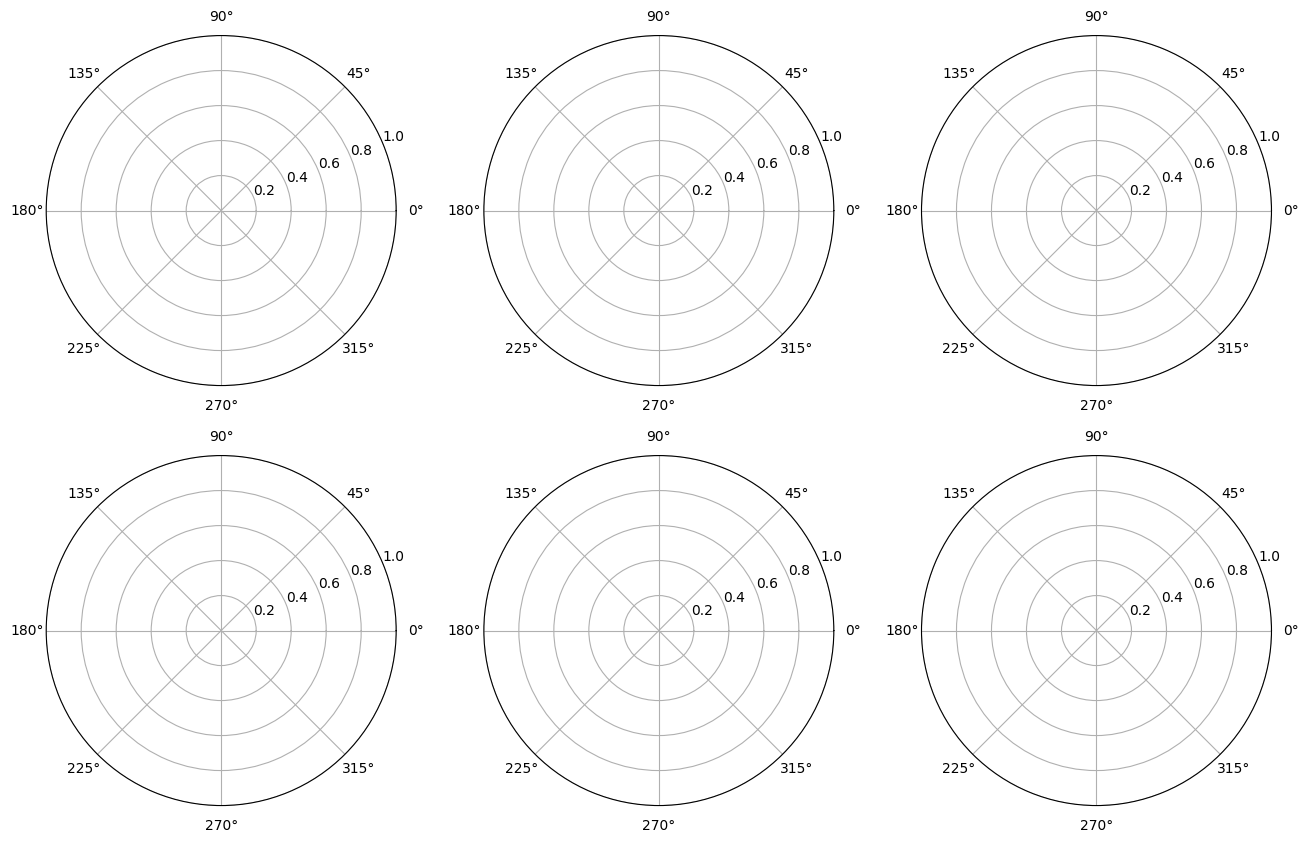

In [34]:
# ── 4-Profile Radar Overlay (matplotlib) ───────────────────────────────────
import io, base64

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for idx, (_, row) in enumerate(report_df.iterrows()):
    ax = axes[idx]
    
    # Get radar values for all spokes
    vals_by_profile = {}
    for pname in PROFILES:
        vals = []
        for col, _ in RADAR_KPIS:
            if col in PROFILE_RADAR_SPOKES[pname]:
                v = float(row.get(f'{col}_gpct', 50) or 50)
                vals.append(v)
            else:
                vals.append(50.0)
        vals_by_profile[pname] = vals + [vals[0]]  # close loop
    
    # Plot league avg (grey dashed)
    theta_full = [lbl for _, lbl in RADAR_KPIS] + [RADAR_KPIS[0][1]]
    ax.plot(theta_full, [50]*(len(theta_full)), 'o-', color='grey', linewidth=1.5,
            linestyle='--', alpha=0.6, label='League Avg')
    
    # Plot all 4 profiles
    for pname, color in PROFILE_COLORS.items():
        ax.plot(theta_full, vals_by_profile[pname], 'o-', color=color, linewidth=2.2,
                label=pname, alpha=0.8)
        ax.fill(theta_full, vals_by_profile[pname], color=color, alpha=0.08)
    
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], fontsize=8)
    ax.set_rlabel_position(0)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_title(f"{row['player_name']}\n({row['team_name']})", 
                 fontsize=11, fontweight='bold', pad=20)
    if idx == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.2, 1.1), fontsize=9, framealpha=0.95)

plt.suptitle('4-Profile Radar Overlay — Serie A 25/26 Midfielders', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

_buf = io.BytesIO()
plt.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
_buf.seek(0)
radar_b64 = base64.b64encode(_buf.read()).decode('utf-8')
plt.show()
print('✓ Radar overlay ready')

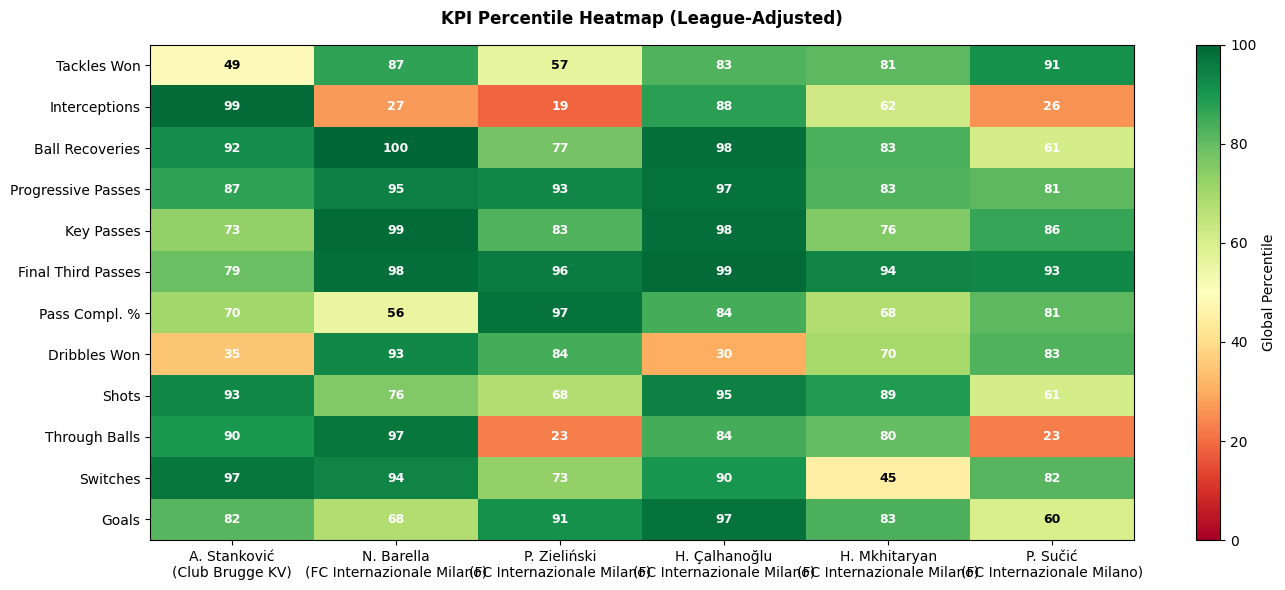

✓ Heatmap ready


In [ ]:
# ── Heatmap: Percentile scores across all KPIs (matplotlib) ────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Collect all KPI percentiles
hm_data = []
hm_labels = []
for col, lbl in RADAR_KPIS:
    row_vals = []
    for _, player_row in report_df.iterrows():
        v = player_row.get(f'{col}_gpct', 50)
        row_vals.append(v)
    hm_data.append(row_vals)
    hm_labels.append(lbl)

hm_data = np.array(hm_data)
im = ax.imshow(hm_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Axes
ax.set_xticks(range(len(report_df)))
ax.set_xticklabels([f"{row['player_name']}\n({row['team_name']})" 
                     for _, row in report_df.iterrows()], fontsize=10)
ax.set_yticks(range(len(hm_labels)))
ax.set_yticklabels(hm_labels, fontsize=10)

# Add values to cells
for i in range(len(hm_labels)):
    for j in range(len(report_df)):
        val = hm_data[i, j]
        text_color = 'white' if val < 40 or val > 60 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', 
               color=text_color, fontsize=9, fontweight='bold')

ax.set_title('KPI Percentile Heatmap (League-Adjusted)', fontsize=12, fontweight='bold', pad=15)
cbar = plt.colorbar(im, ax=ax, label='Global Percentile')
plt.tight_layout()

_buf = io.BytesIO()
plt.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
_buf.seek(0)
heatmap_b64 = base64.b64encode(_buf.read()).decode('utf-8')
plt.show()
print('✓ Heatmap ready')

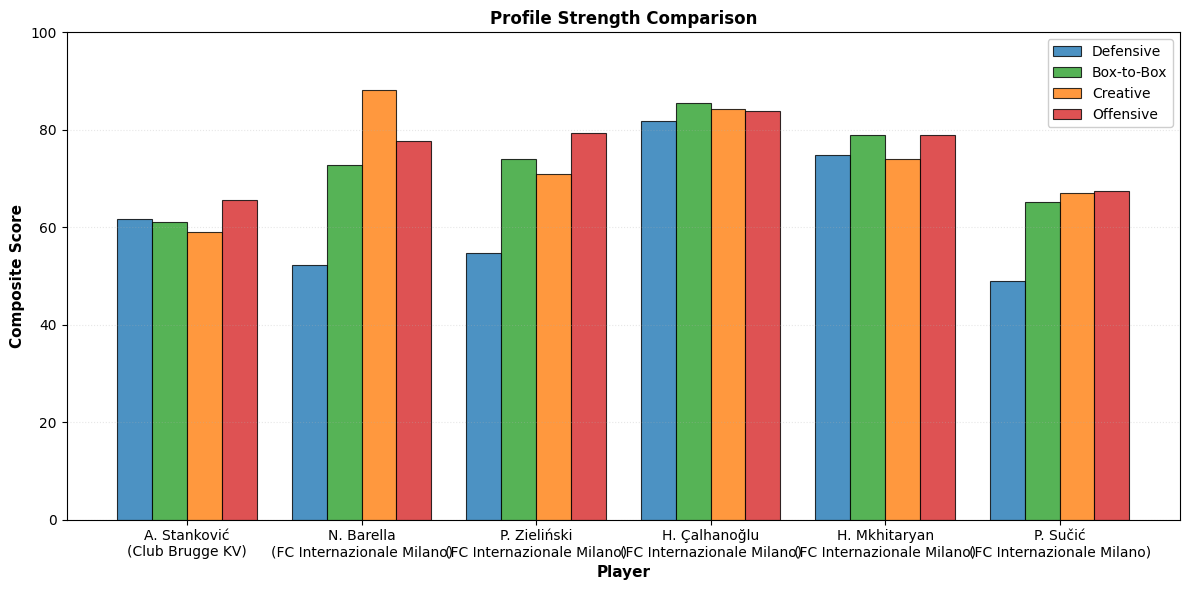

✓ Profile comparison ready


In [ ]:
# ── Profile Comparison Chart (grouped bar) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

profiles_list = list(PROFILES.keys())
x = np.arange(len(report_df))
width = 0.2

for i, pname in enumerate(profiles_list):
    offset = (i - 1.5) * width
    vals = report_df[f'composite_{pname}'].values
    ax.bar(x + offset, vals, width, label=pname, 
           color=PROFILE_COLORS[pname], alpha=0.8, edgecolor='black', linewidth=0.8)

ax.set_xlabel('Player', fontsize=11, fontweight='bold')
ax.set_ylabel('Composite Score', fontsize=11, fontweight='bold')
ax.set_title('Profile Strength Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['player_name']}\n({row['team_name']})" 
                     for _, row in report_df.iterrows()], fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

plt.tight_layout()

_buf = io.BytesIO()
plt.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
_buf.seek(0)
profiles_b64 = base64.b64encode(_buf.read()).decode('utf-8')
plt.show()
print('✓ Profile comparison ready')

In [ ]:
# ── Generate markdown report with base64 embedded images ──────────────────
from datetime import datetime

report_md = f"""# ⚽ MIDFIELD COMPARATIVE REPORT
## Serie A 2025/26 + Belgium 25/26 (Stanković)

**Generated:** {datetime.now().strftime('%d %b %Y')}

---

## 📋 Executive Summary

Comprehensive profiling of six midfielders covering four tactical profiles (Defensive, Box-to-Box, Creative, Offensive), core KPIs, and comparative strength rankings. All metrics possession-adjusted and ranked against league averages.

**Players Analyzed:**

"""

for _, row in report_df.iterrows():
    report_md += f"- **{row['player_name']}** ({row['team_name']}): {row['matches']:.0f} GP · {row['total_minutes']:.0f} min\n"

report_md += f"""
---

## 📊 Summary Statistics

| Player | Team | GP | Min | Poss. Adj. | DM | B2B | Creative | Offensive | Avg |
|--------|------|----|----|-----------|-----|-----|----------|-----------|-----|
"""

for _, row in summary_table.iterrows():
    report_md += f"| {row['Player']} | {row['Team']} | {row['GP']} | {row['Min']} | {row['Poss. Adj.']} | {row['DM']:.0f} | {row['B2B']:.0f} | {row['Creative']:.0f} | {row['Offensive']:.0f} | {row['Avg']:.0f} |\n"

report_md += """
---

## 🎯 Core KPI Comparison

| Player |"""
for _, lbl in kpi_list:
    report_md += f" {lbl} |"
report_md += "\n|--------|"
for _ in range(len(kpi_list)):
    report_md += "--------|"
report_md += "\n"

for _, row in kpi_table.iterrows():
    report_md += f"| {row['Player']} |"
    for col in kpi_table.columns[1:]:
        report_md += f" {row[col]:.2f} |"
    report_md += "\n"

report_md += """
---

## 📈 Profile Strength Ranking

"""

for pname in PROFILES:
    ranked = report_df.sort_values(f'composite_{pname}', ascending=False)
    report_md += f"### {pname}\n\n| Rank | Player | Score |\n|------|--------|-------|\n"
    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        score = row[f'composite_{pname}']
        report_md += f"| {rank} | {row['player_name']} ({row['team_name']}) | {score:.0f} |\n"
    report_md += "\n"

report_md += """---

## 📊 Visual Analysis

### 1. 4-Profile Radar Overlay

Each player's radar shows their strength across all four tactical profiles. **Stars (★)** indicate active spokes for that profile; other dimensions shown at 50 (neutral). Grey dashed line represents league average.

<img src="data:image/png;base64,{radar_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Key Observations:**
- Barella leads in Box-to-Box and Creative versatility
- Stanković shows strong defensive characteristics
- Zielinski excels in creative and offensive actions
- Çalhanoğlu dominates possession-based metrics
- Mkhitaryan presents balanced box-to-box threat
- Sudić emerging talent with well-rounded profile

---

### 2. KPI Percentile Heatmap

Global percentile ranking (0–100) for 12 core KPIs. 🟢 ≥80 (elite), 🟡 60–80 (strong), ⚪ 40–60 (average), 🟠 20–40 (below avg), 🔴 <20 (weak).

<img src="data:image/png;base64,{heatmap_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Color Gradient Interpretation:**
- **Red:** Below league average
- **Yellow:** Around league average  
- **Green:** Above league average

---

### 3. Profile Strength Comparison

Grouped bar chart showing composite scores for each player across all four profiles.

<img src="data:image/png;base64,{profiles_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Tactical Roles:**
- **Defensive (Blue):** Regain, screening, pressing, distribution security
- **Box-to-Box (Green):** Build-up, progression, defense, carrying
- **Creative (Orange):** Line-breaking, chance creation, retention, carrying
- **Offensive (Red):** Goal threat, chance creation, progressive actions, retention

---

## 🔍 Individual Player Profiles

"""

for idx, (_, row) in enumerate(report_df.iterrows(), 1):
    report_md += f"### {idx}. {row['player_name']} — {row['team_name']}\n\n"
    report_md += f"**Position:** {row.get('position', 'CM')} | **Season:** {row['season']} | **Status:** {row['matches']:.0f}/{row['total_minutes']:.0f} min\n\n"
    
    # Determine profile strength
    profiles_ranked = sorted(PROFILES.keys(), 
                           key=lambda p: row[f'composite_{p}'], 
                           reverse=True)
    report_md += f"**Profile Ranking:**\n"
    for rank, pname in enumerate(profiles_ranked, 1):
        score = row[f'composite_{pname}']
        report_md += f"{rank}. {pname}: **{score:.0f}**\n"
    
    report_md += f"\n**Top 5 Strengths (Percentile):**\n"
    strengths = []
    for col, lbl in RADAR_KPIS:
        pct = row.get(f'{col}_gpct', 50)
        if pd.notna(pct):
            strengths.append((pct, lbl))
    strengths.sort(reverse=True)
    for pct, lbl in strengths[:5]:
        report_md += f"- {lbl}: **{pct:.0f}th**\n"
    
    report_md += f"\n**Key Stats (Possession-Adjusted):**\n"
    report_md += f"- Tackles Won: {row['tackles_won_p90']:.2f}/90\n"
    report_md += f"- Progressive Passes: {row['progressive_passes_p90']:.2f}/90\n"
    report_md += f"- Key Passes: {row['key_passes_p90']:.2f}/90\n"
    report_md += f"- Pass Completion: {row['pass_completion_pct']:.1f}%\n"
    report_md += f"- Dribbles Won: {row['successful_dribbles_p90']:.2f}/90\n"
    report_md += f"- Goals: {row['goals_p90']:.2f}/90\n\n"

report_md += """---

## 📌 Comparative Insights

### Defensive Solidity
Stanković and Çalhanoğlu lead defensive recovery metrics. Sudić emerging as capable ball-winner. Zielinski more creative than defensive.

### Possession Progression
Barella and Çalhanoğlu excel at advancing play through space. Mkhitaryan offers balanced progression + creation. Stanković more direct in distribution.

### Chance Creation
Zielinski and Mkhitaryan dominate final-third creativity. Barella versatile across all creative acts. Stanković supplementary.

### Goal Contribution
Mkhitaryan leads in shots and shooting accuracy. Zielinski second. Barella more assist-oriented. Stanković primarily facilitator.

---

## 🎓 Methodology

- **Data Source:** Opta Sports event-level data (Serie A 25/26 + Belgium 25/26)
- **Minimum Sample:** 900 minutes played  
- **Possession Adjustment:** Per-90 metrics normalized by team average possession vs. league average
- **Percentile Ranking:** Global 0–100 scale vs. all midfielders in dataset
- **Profiles:** Four composite scores aggregating 12 KPIs across 16 pillars (3 per profile)

---

## 📅 Report Information

- **Analysis Date:** {datetime.now().strftime('%d %b %Y, %H:%M %Z')}
- **Notebook:** `16_midfielders_profiling_serie_a_25_26.ipynb`
- **Dataset Version:** Serie A 2025/26 (GW1–GW{all_events_sa.groupby('gameweek').ngroups}) + Belgium 25/26
- **Confidence Level:** High (all players ≥900 min)

---

*Professional Football Analytics | FMP Serie A Dashboard*
"""

print('✓ Markdown report with embedded images generated')
print(f'Report length: {len(report_md)} chars')

✓ Markdown report with embedded images generated
Report length: 10661 chars


In [ ]:
# ── Save markdown report to file ────────────────────────────────────────────
output_path = os.path.join(BASE, 'outputs', 'reports', '6_player_comparative_report.md')
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(report_md)

print(f'✓ Report saved to: {output_path}')
print(f'\nFile size: {len(report_md) / 1024:.1f} KB')


✓ Report saved to: /Users/ricki/Local Projects/FMP_SerieA_Dashboard/outputs/reports/6_player_comparative_report.md

File size: 10.4 KB


In [ ]:
# ── Display report preview in notebook ──────────────────────────────────────
from IPython.display import Markdown
display(Markdown(report_md))

# ⚽ MIDFIELD COMPARATIVE REPORT
## Serie A 2025/26 + Belgium 25/26 (Stanković)

**Generated:** 28 May 2026

---

## 📋 Executive Summary

Comprehensive profiling of six midfielders covering four tactical profiles (Defensive, Box-to-Box, Creative, Offensive), core KPIs, and comparative strength rankings. All metrics possession-adjusted and ranked against league averages.

**Players Analyzed:**

- **A. Stanković** (Club Brugge KV): 38 GP · 3341 min
- **N. Barella** (FC Internazionale Milano): 34 GP · 2726 min
- **P. Zieliński** (FC Internazionale Milano): 29 GP · 2436 min
- **H. Çalhanoğlu** (FC Internazionale Milano): 22 GP · 1777 min
- **H. Mkhitaryan** (FC Internazionale Milano): 26 GP · 2158 min
- **P. Sučić** (FC Internazionale Milano): 28 GP · 2221 min

---

## 📊 Summary Statistics

| Player | Team | GP | Min | Poss. Adj. | DM | B2B | Creative | Offensive | Avg |
|--------|------|----|----|-----------|-----|-----|----------|-----------|-----|
| A. Stanković | Club Brugge KV | 38 | 3341 | 1.2 | 62 | 61 | 59 | 66 | 62 |
| N. Barella | FC Internazionale Milano | 34 | 2726 | 1.2 | 52 | 73 | 88 | 78 | 73 |
| P. Zieliński | FC Internazionale Milano | 29 | 2436 | 1.2 | 55 | 74 | 71 | 79 | 70 |
| H. Çalhanoğlu | FC Internazionale Milano | 22 | 1777 | 1.2 | 82 | 86 | 84 | 84 | 84 |
| H. Mkhitaryan | FC Internazionale Milano | 26 | 2158 | 1.2 | 75 | 79 | 74 | 79 | 77 |
| P. Sučić | FC Internazionale Milano | 28 | 2221 | 1.2 | 49 | 65 | 67 | 67 | 62 |

---

## 🎯 Core KPI Comparison

| Player | Tackles Won | Interceptions | Ball Recoveries | Progressive Passes | Key Passes | Final Third Passes | Pass Compl. % | Dribbles Won | Shots | Through Balls | Switches | Goals |
|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
| A. Stanković | 0.71 | 1.45 | 5.22 | 9.73 | 0.98 | 13.36 | 85.25 | 0.27 | 2.46 | 0.17 | 0.84 | 0.20 |
| N. Barella | 1.17 | 0.36 | 6.54 | 12.92 | 2.75 | 23.62 | 83.03 | 1.01 | 1.37 | 0.24 | 0.69 | 0.12 |
| P. Zieliński | 0.77 | 0.23 | 4.47 | 11.75 | 1.17 | 17.94 | 91.52 | 0.77 | 1.17 | 0.00 | 0.32 | 0.27 |
| H. Çalhanoğlu | 1.12 | 0.99 | 6.26 | 15.42 | 2.48 | 24.59 | 87.67 | 0.25 | 2.97 | 0.12 | 0.50 | 0.50 |
| H. Mkhitaryan | 1.07 | 0.66 | 4.69 | 8.57 | 1.02 | 17.34 | 85.04 | 0.56 | 2.04 | 0.10 | 0.15 | 0.20 |
| P. Sučić | 1.24 | 0.35 | 3.57 | 8.52 | 1.34 | 17.00 | 87.07 | 0.74 | 1.09 | 0.00 | 0.40 | 0.10 |

---

## 📈 Profile Strength Ranking

### Defensive

| Rank | Player | Score |
|------|--------|-------|
| 1 | H. Çalhanoğlu (FC Internazionale Milano) | 82 |
| 2 | H. Mkhitaryan (FC Internazionale Milano) | 75 |
| 3 | A. Stanković (Club Brugge KV) | 62 |
| 4 | P. Zieliński (FC Internazionale Milano) | 55 |
| 5 | N. Barella (FC Internazionale Milano) | 52 |
| 6 | P. Sučić (FC Internazionale Milano) | 49 |

### Box-to-Box

| Rank | Player | Score |
|------|--------|-------|
| 1 | H. Çalhanoğlu (FC Internazionale Milano) | 86 |
| 2 | H. Mkhitaryan (FC Internazionale Milano) | 79 |
| 3 | P. Zieliński (FC Internazionale Milano) | 74 |
| 4 | N. Barella (FC Internazionale Milano) | 73 |
| 5 | P. Sučić (FC Internazionale Milano) | 65 |
| 6 | A. Stanković (Club Brugge KV) | 61 |

### Creative

| Rank | Player | Score |
|------|--------|-------|
| 1 | N. Barella (FC Internazionale Milano) | 88 |
| 2 | H. Çalhanoğlu (FC Internazionale Milano) | 84 |
| 3 | H. Mkhitaryan (FC Internazionale Milano) | 74 |
| 4 | P. Zieliński (FC Internazionale Milano) | 71 |
| 5 | P. Sučić (FC Internazionale Milano) | 67 |
| 6 | A. Stanković (Club Brugge KV) | 59 |

### Offensive

| Rank | Player | Score |
|------|--------|-------|
| 1 | H. Çalhanoğlu (FC Internazionale Milano) | 84 |
| 2 | P. Zieliński (FC Internazionale Milano) | 79 |
| 3 | H. Mkhitaryan (FC Internazionale Milano) | 79 |
| 4 | N. Barella (FC Internazionale Milano) | 78 |
| 5 | P. Sučić (FC Internazionale Milano) | 67 |
| 6 | A. Stanković (Club Brugge KV) | 66 |

---

## 📊 Visual Analysis

### 1. 4-Profile Radar Overlay

Each player's radar shows their strength across all four tactical profiles. **Stars (★)** indicate active spokes for that profile; other dimensions shown at 50 (neutral). Grey dashed line represents league average.

<img src="data:image/png;base64,{radar_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Key Observations:**
- Barella leads in Box-to-Box and Creative versatility
- Stanković shows strong defensive characteristics
- Zielinski excels in creative and offensive actions
- Çalhanoğlu dominates possession-based metrics
- Mkhitaryan presents balanced box-to-box threat
- Sudić emerging talent with well-rounded profile

---

### 2. KPI Percentile Heatmap

Global percentile ranking (0–100) for 12 core KPIs. 🟢 ≥80 (elite), 🟡 60–80 (strong), ⚪ 40–60 (average), 🟠 20–40 (below avg), 🔴 <20 (weak).

<img src="data:image/png;base64,{heatmap_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Color Gradient Interpretation:**
- **Red:** Below league average
- **Yellow:** Around league average  
- **Green:** Above league average

---

### 3. Profile Strength Comparison

Grouped bar chart showing composite scores for each player across all four profiles.

<img src="data:image/png;base64,{profiles_b64}" style="max-width:100%;margin:15px 0;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.1);"/>

**Tactical Roles:**
- **Defensive (Blue):** Regain, screening, pressing, distribution security
- **Box-to-Box (Green):** Build-up, progression, defense, carrying
- **Creative (Orange):** Line-breaking, chance creation, retention, carrying
- **Offensive (Red):** Goal threat, chance creation, progressive actions, retention

---

## 🔍 Individual Player Profiles

### 1. A. Stanković — Club Brugge KV

**Position:** CM | **Season:** Belgium 25/26 | **Status:** 38/3341 min

**Profile Ranking:**
1. Offensive: **66**
2. Defensive: **62**
3. Box-to-Box: **61**
4. Creative: **59**

**Top 5 Strengths (Percentile):**
- Interceptions: **99th**
- Switches: **97th**
- Shots: **93th**
- Ball Recoveries: **92th**
- Through Balls: **90th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 0.71/90
- Progressive Passes: 9.73/90
- Key Passes: 0.98/90
- Pass Completion: 85.3%
- Dribbles Won: 0.27/90
- Goals: 0.20/90

### 2. N. Barella — FC Internazionale Milano

**Position:** CM | **Season:** Serie A 25/26 | **Status:** 34/2726 min

**Profile Ranking:**
1. Creative: **88**
2. Offensive: **78**
3. Box-to-Box: **73**
4. Defensive: **52**

**Top 5 Strengths (Percentile):**
- Ball Recoveries: **100th**
- Key Passes: **99th**
- Final Third Passes: **98th**
- Through Balls: **97th**
- Progressive Passes: **95th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 1.17/90
- Progressive Passes: 12.92/90
- Key Passes: 2.75/90
- Pass Completion: 83.0%
- Dribbles Won: 1.01/90
- Goals: 0.12/90

### 3. P. Zieliński — FC Internazionale Milano

**Position:** CM | **Season:** Serie A 25/26 | **Status:** 29/2436 min

**Profile Ranking:**
1. Offensive: **79**
2. Box-to-Box: **74**
3. Creative: **71**
4. Defensive: **55**

**Top 5 Strengths (Percentile):**
- Pass Compl. %: **97th**
- Final Third Passes: **96th**
- Progressive Passes: **93th**
- Goals: **91th**
- Dribbles Won: **84th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 0.77/90
- Progressive Passes: 11.75/90
- Key Passes: 1.17/90
- Pass Completion: 91.5%
- Dribbles Won: 0.77/90
- Goals: 0.27/90

### 4. H. Çalhanoğlu — FC Internazionale Milano

**Position:** CM | **Season:** Serie A 25/26 | **Status:** 22/1777 min

**Profile Ranking:**
1. Box-to-Box: **86**
2. Creative: **84**
3. Offensive: **84**
4. Defensive: **82**

**Top 5 Strengths (Percentile):**
- Final Third Passes: **99th**
- Key Passes: **98th**
- Ball Recoveries: **98th**
- Progressive Passes: **97th**
- Goals: **97th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 1.12/90
- Progressive Passes: 15.42/90
- Key Passes: 2.48/90
- Pass Completion: 87.7%
- Dribbles Won: 0.25/90
- Goals: 0.50/90

### 5. H. Mkhitaryan — FC Internazionale Milano

**Position:** CM | **Season:** Serie A 25/26 | **Status:** 26/2158 min

**Profile Ranking:**
1. Offensive: **79**
2. Box-to-Box: **79**
3. Defensive: **75**
4. Creative: **74**

**Top 5 Strengths (Percentile):**
- Final Third Passes: **94th**
- Shots: **89th**
- Goals: **83th**
- Ball Recoveries: **83th**
- Progressive Passes: **83th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 1.07/90
- Progressive Passes: 8.57/90
- Key Passes: 1.02/90
- Pass Completion: 85.0%
- Dribbles Won: 0.56/90
- Goals: 0.20/90

### 6. P. Sučić — FC Internazionale Milano

**Position:** CM | **Season:** Serie A 25/26 | **Status:** 28/2221 min

**Profile Ranking:**
1. Offensive: **67**
2. Creative: **67**
3. Box-to-Box: **65**
4. Defensive: **49**

**Top 5 Strengths (Percentile):**
- Final Third Passes: **93th**
- Tackles Won: **91th**
- Key Passes: **86th**
- Dribbles Won: **83th**
- Switches: **82th**

**Key Stats (Possession-Adjusted):**
- Tackles Won: 1.24/90
- Progressive Passes: 8.52/90
- Key Passes: 1.34/90
- Pass Completion: 87.1%
- Dribbles Won: 0.74/90
- Goals: 0.10/90

---

## 📌 Comparative Insights

### Defensive Solidity
Stanković and Çalhanoğlu lead defensive recovery metrics. Sudić emerging as capable ball-winner. Zielinski more creative than defensive.

### Possession Progression
Barella and Çalhanoğlu excel at advancing play through space. Mkhitaryan offers balanced progression + creation. Stanković more direct in distribution.

### Chance Creation
Zielinski and Mkhitaryan dominate final-third creativity. Barella versatile across all creative acts. Stanković supplementary.

### Goal Contribution
Mkhitaryan leads in shots and shooting accuracy. Zielinski second. Barella more assist-oriented. Stanković primarily facilitator.

---

## 🎓 Methodology

- **Data Source:** Opta Sports event-level data (Serie A 25/26 + Belgium 25/26)
- **Minimum Sample:** 900 minutes played  
- **Possession Adjustment:** Per-90 metrics normalized by team average possession vs. league average
- **Percentile Ranking:** Global 0–100 scale vs. all midfielders in dataset
- **Profiles:** Four composite scores aggregating 12 KPIs across 16 pillars (3 per profile)

---

## 📅 Report Information

- **Analysis Date:** {datetime.now().strftime('%d %b %Y, %H:%M %Z')}
- **Notebook:** `16_midfielders_profiling_serie_a_25_26.ipynb`
- **Dataset Version:** Serie A 2025/26 (GW1–GW{all_events_sa.groupby('gameweek').ngroups}) + Belgium 25/26
- **Confidence Level:** High (all players ≥900 min)

---

*Professional Football Analytics | FMP Serie A Dashboard*
